# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Maria Reina Zarate Nava

# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Nota: 
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#Cargamos el dataSet sucio
dfSucio = pd.read_csv("ventas-por-factura.csv")

In [5]:
dfSucio.shape

(25953, 6)

In [6]:
dfSucio.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [7]:
dfSucio.tail()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,"720,00"
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,"298,78"
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,"1488,00"
25952,537999,12/9/2020 11:44:00,NaN,United Kingdom,-223,"0,00"


In [8]:
#Se han identificado valores  negativos o fuera de rango en las columnas: cantidad y monto. Así comoo clientes sin ID


In [9]:
dfSucio.describe()

,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [13]:
dfSucio[dfSucio["ID Cliente"].isin([12346, 15465, 18287])]

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
229,C544442,2/20/2021 10:30:00,15465.0,United Kingdom,-3,"-32,85"
1234,558747,7/3/2021 10:11:00,15465.0,United Kingdom,53,"318,91"
1457,C541433,1/18/2021 10:17:00,12346.0,United Kingdom,-74215,"-77183,60"
1574,547835,3/27/2021 10:18:00,15465.0,United Kingdom,51,"485,45"
1940,C550751,4/20/2021 11:48:00,15465.0,United Kingdom,-2,"-25,50"
2919,561021,7/24/2021 10:03:00,15465.0,United Kingdom,61,"320,71"
3291,C547836,3/27/2021 10:19:00,15465.0,United Kingdom,-9,"-98,55"
6447,556466,6/12/2021 11:07:00,15465.0,United Kingdom,31,"189,05"
6988,544440,2/20/2021 10:28:00,15465.0,United Kingdom,80,"645,56"
7737,538996,12/15/2020 12:06:00,15465.0,United Kingdom,38,"332,10"


In [8]:
#Valores nulos
dfSucio.isnull().sum()

N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0
dtype: int64

In [4]:
# Para revisar máximos y mínimos sospechosos (ej. montos negativos o edades de 200 años)
dfSucio.describe()

,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [9]:
# Facturas canceladas
canceladas = dfSucio[dfSucio['N° de factura'].str.contains('C', na=False)]
print(f"Total de facturas canceladas: {len(canceladas)}")

Total de facturas canceladas: 3841


In [10]:
dfSucio.duplicated().sum()

np.int64(10)

In [12]:
dfSucio.dtypes
# Fecha es tipo 'object' y un Monto tiene símbolos de dinero y es 'object'

N° de factura        object
Fecha de factura     object
ID Cliente          float64
País                 object
Cantidad              int64
Monto                object
dtype: object

In [13]:
# 1. Copia de seguridad
dfLimpio = dfSucio.copy()

In [15]:
# 2. Corregir tipo de dato de fecha
dfLimpio['Fecha de factura'] = pd.to_datetime(dfLimpio['Fecha de factura'], errors='coerce')

In [16]:
dfLimpio.dtypes

N° de factura               object
Fecha de factura    datetime64[ns]
ID Cliente                 float64
País                        object
Cantidad                     int64
Monto                       object
dtype: object

In [17]:
if dfLimpio['Monto'].dtype == 'object':
    dfLimpio['Monto'] = dfLimpio['Monto'].str.replace('$', '').str.replace(',', '').astype(float)

In [18]:
dfLimpio.dtypes

N° de factura               object
Fecha de factura    datetime64[ns]
ID Cliente                 float64
País                        object
Cantidad                     int64
Monto                      float64
dtype: object

In [19]:
# 3. Eliminar duplicados exactos
dfLimpio = dfLimpio.drop_duplicates()

In [22]:
# Creamos la nueva columna llamada 'Estado'
dfSucio['Estado'] = np.where(dfSucio['N° de factura'].astype(str).str.contains('C', na=False), 'Cancelado', 'Valido')

In [23]:
dfSucio.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Estado
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33",Valido
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73",Valido
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45",Cancelado
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95",Valido
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83",Valido


In [24]:
dfLimpio['Estado'] = np.where(dfLimpio['N° de factura'].astype(str).str.contains('C', na=False), 'Cancelado', 'Valido')

In [25]:
dfLimpio.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Estado
0,548370,2021-03-30 16:14:00,15528.0,United Kingdom,123,22933.0,Valido
1,575767,2021-11-11 11:11:00,17348.0,United Kingdom,163,20973.0,Valido
2,C570727,2021-10-12 11:32:00,12471.0,Germany,-1,-145.0,Cancelado
3,549106,2021-04-06 12:08:00,17045.0,United Kingdom,1,3995.0,Valido
4,573112,2021-10-27 15:33:00,16416.0,United Kingdom,357,34483.0,Valido


In [26]:
# 5. Tratar Outliers y Negativos en Monto
dfLimpio = dfLimpio[dfLimpio['Monto'] > 0]

In [27]:
dfLimpio.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Estado
0,548370,2021-03-30 16:14:00,15528.0,United Kingdom,123,22933.0,Valido
1,575767,2021-11-11 11:11:00,17348.0,United Kingdom,163,20973.0,Valido
3,549106,2021-04-06 12:08:00,17045.0,United Kingdom,1,3995.0,Valido
4,573112,2021-10-27 15:33:00,16416.0,United Kingdom,357,34483.0,Valido
5,576630,2021-11-16 08:38:00,13816.0,Germany,91,19998.0,Valido


In [28]:
#6. Tratar valores nulos 
dfLimpio['Monto'] = dfLimpio['Monto'].fillna(dfLimpio['Monto'].median())

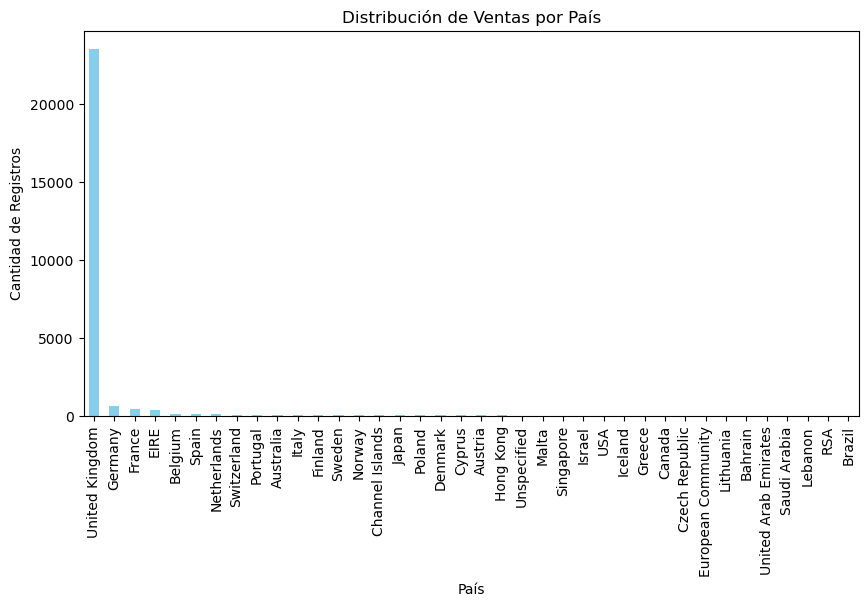

In [30]:
# Grafica de ventas por pais
plt.figure(figsize=(10, 5))
dfSucio['País'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribución de Ventas por País')
plt.xlabel('País')
plt.ylabel('Cantidad de Registros')
plt.show()

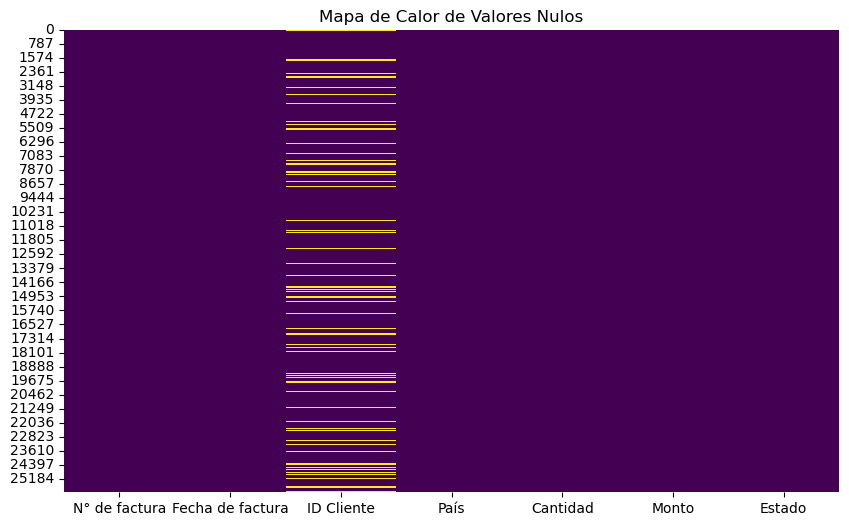

In [31]:
# Heatmap de Valores Nulos
plt.figure(figsize=(10, 6))
sns.heatmap(dfSucio.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Nulos')
plt.show()

In [33]:
# Distribución del Monto
plt.figure(figsize=(10, 4))
sns.boxplot(x=dfSucio['Monto'], color='lightcoral')
plt.title('Distribución y Detección de Outliers en el Monto')
plt.show()


KeyboardInterrupt



In [34]:
# Exportar el dataset limpio
dfLimpio.to_csv('Data_Limpio_Factura.csv', index=False, encoding='utf-8')